<a href="https://colab.research.google.com/github/NataliiaFakas/TFG_BMW/blob/main/2_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probando Random Forests
---
Para esta parte, vamos a utilizar el modelo `RandomForestRegressor` de la librería `scikit-learn`:

* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#randomforestregressor

Para hacer lo siguiente:

* **Matriz X de NxD** (variables macroeconómicas)
  - N = número de muestras (filas) → cada fila corresponde a un año.
  - D = número de características macroeconómicas seleccionadas (columnas).
  - Representa toda la información macroeconómica disponible para cada año.

* **Vector y de Nx1**
  - Cada valor de `y` corresponde a las ventas de coches BMW en ese año (`Sales_Volume`).
  - Cada fila de X debe estar alineada con su valor correspondiente en y para que el modelo aprenda correctamente la relación temporal.

* **Entrenar el Random Forest**
  - Se crea un modelo `RandomForestRegressor` con suficientes árboles (`n_estimators=100`) y un `random_state` fijo para reproducibilidad.
  - Se entrena el modelo usando `X` e `y` con el método `.fit()`.
  - Esto permite al modelo aprender qué variables macroeconómicas tienen más impacto sobre las ventas de BMW.

* **Interpretar las importancias de las variables**
  - Una vez entrenado, se puede examinar `modelo.feature_importances_`.
  - Indica la importancia relativa de cada variable según la disminución media de la impureza (MSE) en la regresión.
  - Variables con valores cercanos a cero son menos relevantes y pueden descartarse.



---
# Vamos con el código:
##1. Primero cargamos el dataset:





In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_final.csv" #Cargamos el dataset entero

df = pd.read_csv(ruta, sep=';')
df.head()

Mounted at /content/drive


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,...,Deposit_facility,HICP,Crec_demog,Prod_Ind,Ventas_Ret,Conf_Cons,Salario_Mes,Euríbor,Precio del crudo,EUR/USD
0,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949,...,2.75,8.37,28330546.03,3.0,0.02,-24,0.06,2.5,0.43,1.05
1,i8,2019,Europe,White,Electric,Manual,3.0,35700,96257,4411,...,3.50,1.19,28330248.63,-1.0,0.01,-8,0.03,NaN,-0.10,1.12
2,M5,2011,Europe,Grey,Electric,Automatic,3.3,78042,49507,9383,...,2.00,2.70,27943664.50,1.0,0.01,-15,2.70,1.7,0.40,1.39
3,i8,2023,Europe,Blue,Diesel,Automatic,3.8,78573,118317,7168,...,2.50,5.46,28441896.69,-2.0,0.01,-18,0.04,3.9,-0.18,1.08
4,M3,2014,Europe,Red,Electric,Manual,2.5,74474,65464,9390,...,3.25,0.44,28067113.84,2.0,0.01,-12,0.03,0.2,-0.09,1.33


Como tenemos muchas filas por año, vamos a agruparlo todo en una fila por año:

In [5]:
# Limpiamos primero las columnas, las listamos y así podemos agruparlas después
df.columns = df.columns.str.strip() \
                       .str.replace(' ', '_', regex=False) \
                       .str.replace('/', '_', regex=False) \
                       .str.replace('í', 'i', regex=False)
print(df.columns.tolist())

['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume', 'Sales_Classification', 'Unemployment_Rate', 'GDP_Growth', 'Deposit_facility', 'HICP', 'Crec_demog', 'Prod_Ind', 'Ventas_Ret', 'Conf_Cons', 'Salario_Mes', 'Euribor', 'Precio_del_crudo', 'EUR_USD']


In [6]:
df_year = df.groupby("Year").agg({
    "Sales_Volume": "sum",
    "Unemployment_Rate": "mean",
    "Deposit_facility": "mean",
    "HICP": "mean",
    "Crec_demog": "mean",
    "Prod_Ind": "mean",
    "Ventas_Ret": "mean",
    "Conf_Cons": "mean",
    "Salario_Mes": "mean",
    "Euribor": "mean",
    "Precio_del_crudo": "mean",
    "EUR_USD": "mean"
}).reset_index()

df_year.head()

,Year,Sales_Volume,Unemployment_Rate,Deposit_facility,HICP,Crec_demog,Prod_Ind,Ventas_Ret,Conf_Cons,Salario_Mes,Euribor,Precio_del_crudo,EUR_USD
0,2010,2775123,13.100000,1.50,1.62,27978709.91,8.0,0.02,-17.0,1.50,1.4,0.29,1.33
1,2011,2862580,13.100000,2.00,2.70,27943664.50,1.0,0.01,-15.0,2.70,1.7,0.40,1.39
2,2012,2896866,14.266667,2.50,2.50,27995530.13,-1.0,0.00,-22.0,0.03,0.6,0.00,1.29
3,2013,2699439,14.866667,3.00,1.35,28029028.13,1.0,0.01,-19.0,0.03,0.4,-0.03,1.33
4,2014,2653563,14.200000,3.25,0.44,28067113.84,2.0,0.01,-12.0,0.03,0.2,-0.09,1.33


Ahora creamos X e Y:

In [7]:
# Variable objetivo
y = df_year["Sales_Volume"]

# Variables macro
X = df_year.drop(columns=["Year", "Sales_Volume"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15, 11)
y shape: (15,)


In [8]:
print(df_year[["Year", "Sales_Volume"]])

    Year  Sales_Volume
0   2010       2775123
1   2011       2862580
2   2012       2896866
3   2013       2699439
4   2014       2653563
5   2015       2712709
6   2016       2709724
7   2017       2843387
8   2018       2738873
9   2019       3096885
10  2020       2811188
11  2021       2944050
12  2022       3038459
13  2023       2739248
14  2024       3033044


Ya tenemos todo listo para poder entrenar el modelo
---
## 2. Entrenar el modelo

Ahora que tenemos las matrices, vamos a hacer lo siguiente:

* Importamos el modelo, lo creamos y lo entrenamos:


In [10]:
from sklearn.ensemble import RandomForestRegressor

# Creamos el Random Forest con 100 árboles y semilla fija para reproducibilidad
modelo = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenamos el modelo con X e Y
modelo.fit(X, y)

RandomForestRegressor(random_state=42)

             Variable  Importancia
0   Unemployment_Rate     0.304869
2                HICP     0.171751
9    Precio_del_crudo     0.152614
3          Crec_demog     0.125803
8             Euribor     0.059224
6           Conf_Cons     0.054362
5          Ventas_Ret     0.037270
4            Prod_Ind     0.036143
1    Deposit_facility     0.026532
10            EUR_USD     0.025145
7         Salario_Mes     0.006287


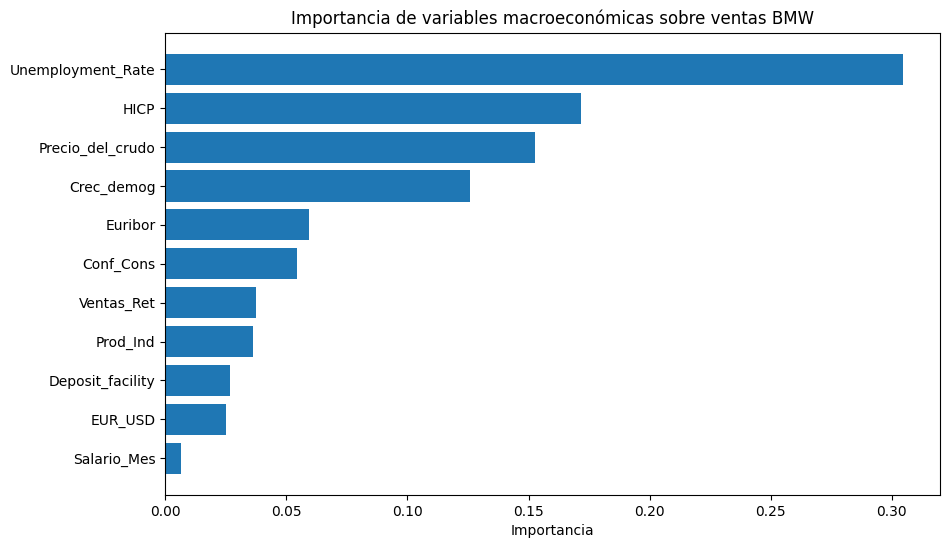

In [12]:
import pandas as pd

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print(importancias)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importancias["Variable"], importancias["Importancia"])
plt.xlabel("Importancia")
plt.title("Importancia de variables macroeconómicas sobre ventas BMW")
plt.gca().invert_yaxis()  # Para que la variable más importante esté arriba
plt.show()

---
#Conclusión
Podemos concluir que la variable **más relevante** es `Unemployment_Rate`, seguida de **HICP**, **Precio_del_crudo** y **Crec_demog**.

No obstante, otras variables como `Euribor`, `Conf_Cons`, `Ventas_Ret` y `Prod_Ind` tienen **importancia moderada**, aportando algo al modelo porque se acercan más a cero.

* Las demás variables (`Salario_Mes`, `Deposit_facility`, `EUR_USD`) se acercan mucho a cero. Y por tanto, son **irrelevantes**
